---
title: QQ Plots
subtitle: DS 2023 | Communicating with Data
---

:::{image}images/qq-plot.png
:width: 500px
:align: left
:::

## Overview

In the same way that a histogram is a special case of a bar chart, a Q-Q plot is a special case of a scatter plot.

It plots two numeric statistical features on the x and y axes, usually the quantiles of two probability distributions, $Q_1$ and $Q_2$.

Hence the name "Q–Q" &mdash; short for quantile–quantile.

Q-Q plots also typically add a line plot to the figure as a reference, where $y = x$.

If the sample follows the model, the points will fall along the line.

Systematic departures reveal how the two distributions differ.

$Q_1$ and $Q_2$ are often a model and sample, respectively, but sometimes they are two samples.


## Use Cases

Like histograms, Q-Q plots allow the user to quickly see the statistical properties of a distribution, such as skew, tails, and outliers. 

However, Q-Q plots are optimized to show how a distribution differs from a model, such as the normal distribution.

Q-Q plots can also be used to compare two samples to see if they come from the same population.

In either case, the more similar the $Q_1$ and $Q_2$, they more their points will align with the identity line, i.e. the line produced by the function $x = y$.

## Creating a Q-Q plot from scratch

The essential part of creating a Q-Q plot is preparing the data, then displaying them with a scatter plot and a reference line.

When comparing a feature's distribution against a theoretical model, the general data preparation
steps are:

**1. Get sample quantiles.** Choose a numeric feature and sort its values in
   ascending order. Each value then has a rank $r$, typically starting at $1$.
   These sorted values are the sample quantiles, $Q_2$.

**2. Choose a theoretical distribution**. This is the model you want to compare your sample data 
   against. This is often the standard normal distribution.

**3. Compute the plotting positions.** For each rank, calculate a cumulative
   probability, using the formula

   $$p_r = \frac{r - 0.5}{N}$$

   where $r$ is the rank of the data point and $N$ is the total number of
   observations. These are *not* quantiles &mdash; they are evenly spaced
   probabilities in $(0, 1)$.

:::{note}
The formula used here is known as Hazen's formula. Others exist, such as Blom's.

To learn more about these, check out the guide to Q-Q plots offered by [Statistics Fundamentals](https://statisticsfundamentals.com/data-visualization/qq-plots/).
:::

**4. Convert plotting positions into theoretical quantiles.** Pass each $p_r$ to
   the model's *inverse* cumulative distribution function (CDF), also called the
   quantile function.

   For the normal distribution this is $\Phi^{-1}$
   (`norm.ppf`), which warps the uniform probabilities into normally-spaced
   values. The results are the theoretical quantiles, $Q_1$.

**5. Plot the resulting data.** Draw a scatter plot of $Q_1$ (theoretical, x-axis) against $Q_2$
   (sample, y-axis), and overlay the reference line $y = x$.

   Points close to the line indicate a good fit; curves, S-shapes, or bent tails reveal how the
   sample's distribution departs from the model.


Here is an example using NumPy, Pandas, and Matplotlib.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We start by taking a random sample of $100$ observations from the normal distribution.

In [3]:
my_sample = np.random.normal(0, 1, 100)
my_sample[:5]

array([ 0.12530124, -0.22626713,  0.6321465 , -0.69434133, -1.75063475])

We then create a data frame to store the features for our Q-Q plot.

In [4]:
QQ = pd.DataFrame({
    'q2': sorted(my_sample),
    'rank': [i+1 for i in range(len(my_sample))]
})
QQ.head()

,q2,rank
0,-2.550680,1
1,-2.153968,2
2,-1.947456,3
3,-1.795917,4
4,-1.750635,5


Next, we compute the plotting positions, which are just probabilities.

In [5]:
QQ['p'] = (QQ['rank'] - .5) / len(QQ)
QQ.head()

,q2,rank,p
0,-2.550680,1,0.005
1,-2.153968,2,0.015
2,-1.947456,3,0.025
3,-1.795917,4,0.035
4,-1.750635,5,0.045


Finally, we convert the plotting positions into theoretical quantiles. 

Here, we fall back on the SciPy's [`scipy.stats.norm()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) functionto do the heavy lifting.

In [6]:
import scipy.stats as stats
QQ['q1'] = stats.norm.ppf(QQ['p'])
QQ.head()

,q2,rank,p,q1
0,-2.550680,1,0.005,-2.575829
1,-2.153968,2,0.015,-2.170090
2,-1.947456,3,0.025,-1.959964
3,-1.795917,4,0.035,-1.811911
4,-1.750635,5,0.045,-1.695398


Now, we just create a scatter plot with a reference line.

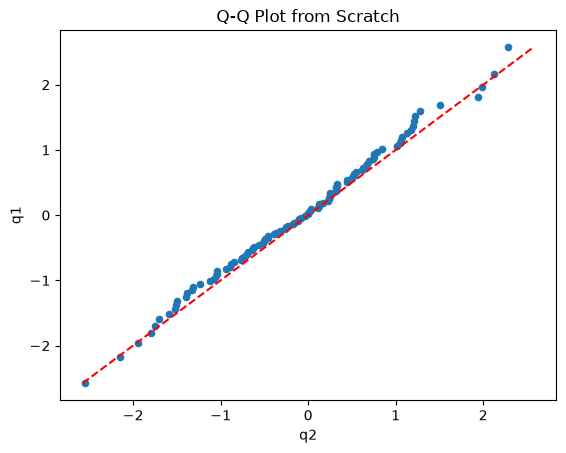

In [16]:
ax = QQ.plot.scatter('q2','q1')
lims = [QQ.q1.min(), QQ.q1.max()]
ax.plot(lims, lims, ls='--', c='red')
ax.set_title("Q-Q Plot from Scratch")
plt.show()

Here is a minimalist version of a function to create a q-q plot.

In [19]:
def qqplot(S):
    q1 = sorted(S)
    p = [(i + 1 - .5) / len(S) for i in range(len(S))]
    q2 = stats.norm.ppf(p)
    fig, ax = plt.subplots()
    ax.plot(q2, q1, 'o')
    limits = [min(q1), max(q1)]
    ax.plot(limits, limits, c='red', ls='-')

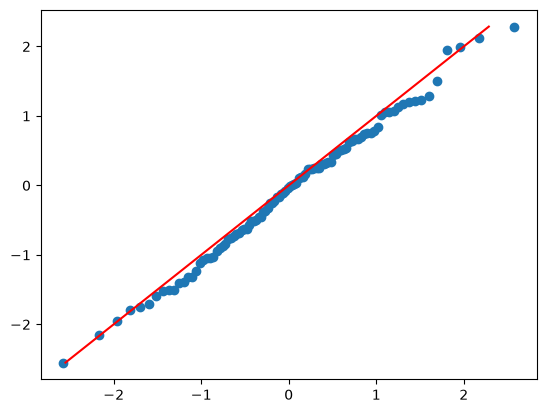

In [20]:
qqplot(my_sample)

## Using SciPy and Statsmdolels

Python's two main statistical libraries, SciPy and Statsmodels, each have functions that will produce a Q-Q plot in Matplotlib for you.

Here is SciPy's [`.stats.probplot()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html) function.

Here we see it with the `plot` argument set, which automatically produces a plot for us.

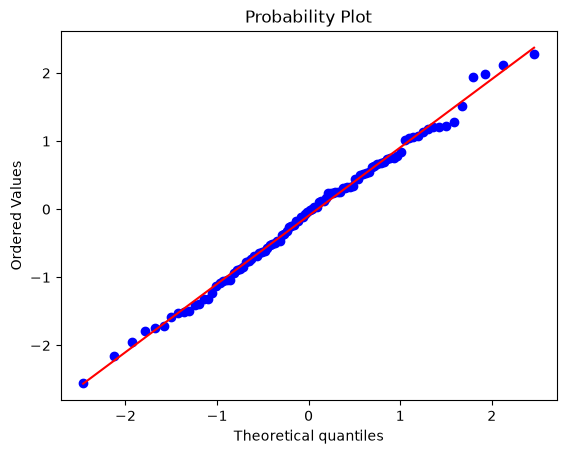

In [21]:
stats.probplot(my_sample, dist="norm", plot=plt)
plt.show()

And here is [the Statsmodels version](https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html), which by default produces a plot.

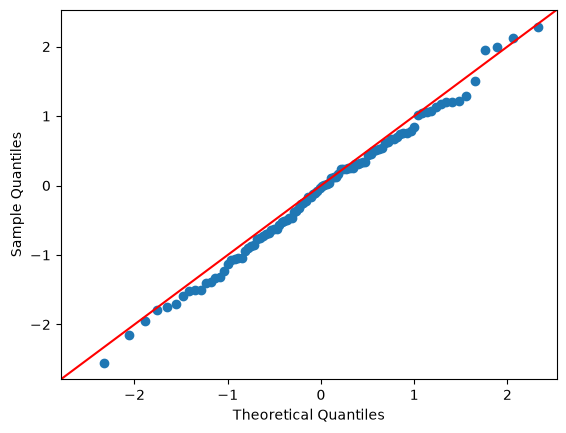

In [22]:
import statsmodels.api as sm

sm.qqplot(my_sample, line ='45')
plt.show()

In both cases, the resulting plot is a Matplotlib object that can be further manipulated using PyPlot (`plt`).

:::{note}
There are some differences between the two libraries' plots. 

They differ in how the reference line is constructed and how the axes are labeled.

Do you notice others?
:::

## Comparison to histrograms and density plots

Let's look at an example of Q-Q plots in comparison to histograms and density plots for investigating the properties of a distribution.

We use the same data set we used when looking at histograms.

In [12]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


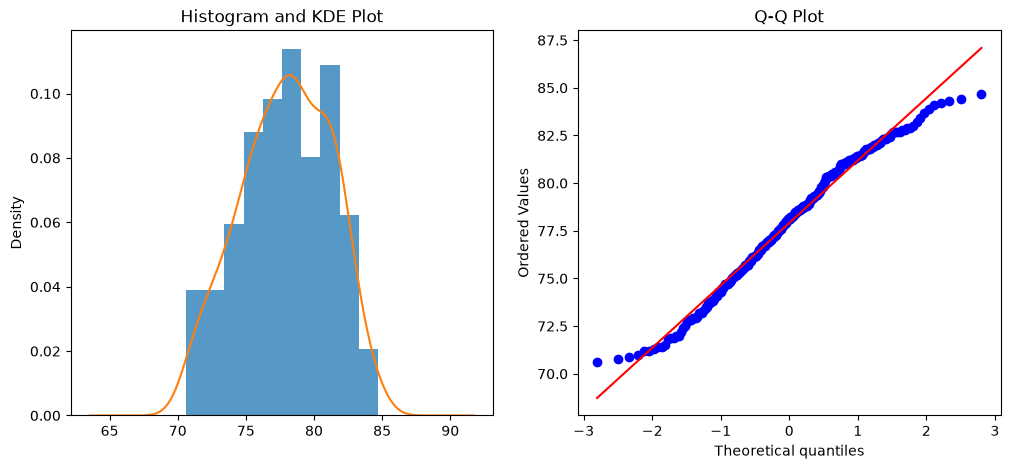

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
healthexp.Life_Expectancy.plot.hist(density=True, alpha=.75)
healthexp.Life_Expectancy.plot.kde()
plt.title("Histogram and KDE Plot")

plt.subplot(1,2,2)
stats.probplot(healthexp.Life_Expectancy, dist="norm", plot=plt)
plt.title("Q-Q Plot")

plt.show()

Looking at the Q-Q plot, we can see two things right away.

First, there is a good **overall fit** through the center of the distribution — roughly the middle two-thirds, between theoretical quantiles of about $−1.5$ and $+1.5$. This means that a normal model describes the bulk of this data well: it's reasonably symmetric with no strong skew, and the central shape is essentially Gaussian.

Second, the curves at either end of the plot reveal something about **the tails** of the distribution. The fact that the points lie *above* the line on the left and *below* it on the right indicates that the most extreme observed values are *less* extreme than a normal distribution would predict. Statisticians would say the distribution has **short, light tails**. 

In both cases, **the Q-Q plot is more informative** than the other two. It immediately directs your attention these facts. In contrast, a histogram's look is sensitive to the number of bins selected, while the KDE's is sensitive to bandwidth, which can smooth away or even invent features. 

Visually, it is important to note that the two on the left spend almost all their visual space (data ink) on the dense center, squashing the sparse tails into near-zero slivers where deviations from normality are almost impossible to see. 

So, while the histogram and KDE are better for conveying overall shape, modality, and the actual data scale to a general audience, the Q-Q plot is the better diagnostic for judging *how* and *where* the distribution departs from a chosen model — especially in the tails, which is exactly where it matters most.